In [3]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

Выбрано c ≈ -1.1547


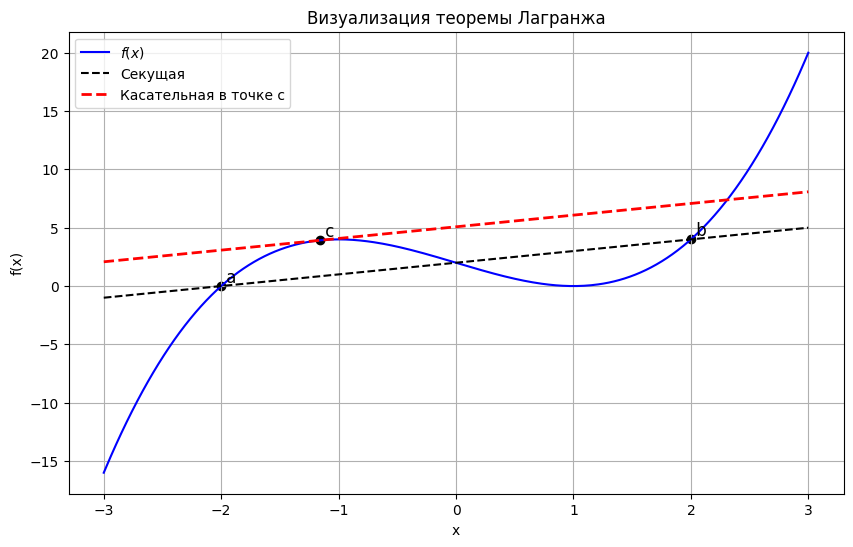

In [48]:
def vizualize_lagrange():
    x = sp.symbols('x')
    f_sym = x ** 3 - 3*x + 2
    f_num = sp.lambdify(x, f_sym, 'numpy')

    # находим производную
    f_diff = sp.diff(f_sym, x)
    f_diff_num = sp.lambdify(x, f_diff, 'numpy')
    
    a, b = -2, 2
    slope_sec = (f_num(b) - f_num(a)) / (b - a)

    # найдем такую точку c, что f'(c) = [ f(b) - f(a) ] / (b - a)
    equation = sp.Eq(f_diff, slope_sec)
    solutions = np.array(sp.solve(equation, x))
    in_ab_solutions = solutions[solutions > a][solutions < b]
    c = in_ab_solutions[0]
    print(f"Выбрано c ≈ {c:.4f}")

    # переходим к построению графика
    x_vals = np.linspace(a - 1, b + 1, 400)
    y_vals = f_num(x_vals)

    f_c = f_num(c)
    secant_line = slope_sec*(x_vals - a) + f_num(a)
    tangent_line = slope_sec * (x_vals - c) + f_c
    
    plt.figure(figsize=(10, 6))
    plt.plot(x_vals, y_vals, label='$f(x)$', color='blue')
    plt.plot(x_vals, secant_line, label='Секущая', color='black', linestyle='--')
    plt.plot(x_vals, tangent_line, label=f'Касательная в точке c', color='red', linestyle='--', linewidth=2)
    plt.scatter([a, b, c], [f_num(a), f_num(b), f_c], color='black')  # отмечаем точки a, b и c
    plt.text(a, f_num(a), ' a', fontsize=12, verticalalignment='bottom')
    plt.text(b, f_num(b), ' b', fontsize=12, verticalalignment='bottom')
    plt.text(c, f_c, ' c', fontsize=12, verticalalignment='bottom')

    plt.title('Визуализация теоремы Лагранжа')
    plt.xlabel('x')
    plt.ylabel('f(x)')
    plt.legend()
    plt.grid()

    plt.savefig('lagrange_theorem.png', format='png', dpi=300)
    plt.show()
    
vizualize_lagrange()

Точное значение интеграла: 13.4612755172573
Приближение методом центральных прямоугольников: 13.549946839026482
Приближение методом трапеций: 13.304325798331764
Приближение методом Симпсона: 13.685067233826135


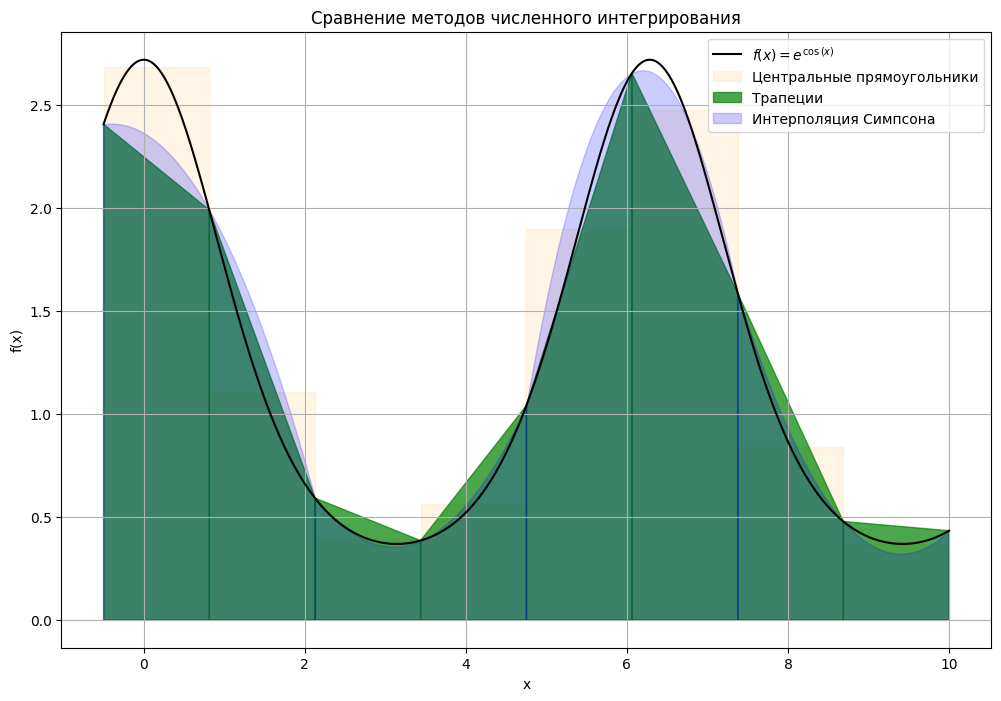

In [72]:
def vizualize_integrals(rect_opacity=0.3, trap_opacity=0.3, simpson_opacity=0.2):
    # 1. Определим символические переменные и функцию
    x = sp.symbols('x')
    F_sym = sp.exp(sp.cos(x))

    func_expr_latex = sp.latex(F_sym)
    a = -0.5
    b = 10
    
    # Преобразуем границы в числовой формат, если нужно
    a_val = float(a)
    b_val = float(b)
    
    # 1) Точное значение интеграла
    exact_integral = sp.N(sp.integrals.integrals.Integral(F_sym, (x, a, b)).doit())
    print(f"Точное значение интеграла: {exact_integral}")
    
    # Преобразуем функцию в числовую для вычислений и графиков
    F_num = sp.lambdify(x, F_sym, 'numpy')
    
    # Задаём количество подынтервалов
    n = 8
    h = (b_val - a_val) / n
    
    x_nodes = np.linspace(a_val, b_val, n+1)
    y_nodes = F_num(x_nodes)
    
    # 2) Метод центральных прямоугольников
    # Используем середины каждого подынтервала
    midpoints = (x_nodes[:-1] + x_nodes[1:]) / 2
    rectangle_areas = F_num(midpoints) * h
    integral_rectangles = np.sum(rectangle_areas)
    print(f"Приближение методом центральных прямоугольников: {integral_rectangles}")
    
    # 3) Метод трапеций
    trapz_areas = (y_nodes[:-1] + y_nodes[1:]) / 2 * h
    integral_trapz = np.sum(trapz_areas)
    print(f"Приближение методом трапеций: {integral_trapz}")
    
    # 4) Метод Симпсона
    # n должно быть чётным, что выполнено (n=8)
    # Используем формулу Симпсона: (h/3)[f(x_0) + 4f(x_1) + 2f(x_2) + ... + 4f(x_{n-1}) + f(x_n)]
    coefficients = np.ones(n+1)
    coefficients[1:-1:2] = 4   # для нечётных индексов
    coefficients[2:-2:2] = 2   # для чётных индексов, кроме концов
    
    integral_simpson = (h/3) * np.sum(coefficients * y_nodes)
    print(f"Приближение методом Симпсона: {integral_simpson}")
    
    # 5. Визуализация
    
    # Создадим плотные точки для функции
    x_fine = np.linspace(a_val, b_val, 400)
    y_fine = F_num(x_fine)
    
    plt.figure(figsize=(12, 8))
    plt.plot(x_fine, y_fine, label=f'$f(x)={func_expr_latex}$', color='black')
    
    # Визуализация метода центральных прямоугольников
    for i in range(n):
        # прямоугольник для каждого интервала
        xi_left = x_nodes[i]
        xi_right = x_nodes[i+1]
        xm = midpoints[i]
        height = F_num(xm)
        plt.fill([xi_left, xi_right, xi_right, xi_left], 
                 [0, 0, height, height], 
                 color='orange', alpha=rect_opacity, label='Центральные прямоугольники' if i==0 else "")
    
    # Визуализация метода трапеций
    for i in range(n):
        xi_left = x_nodes[i]
        xi_right = x_nodes[i+1]
        plt.fill([xi_left, xi_right, xi_right, xi_left], 
                 [0, 0, F_num(xi_right), F_num(xi_left)], 
                 color='green', alpha=trap_opacity, label='Трапеции' if i==0 else "")
    
    # Визуализация метода Симпсона
    # Для отображения полиномиальной аппроксимации на каждом отрезке из 2 интервалов
    for i in range(0, n, 2):  # обрабатываем по два подынтервала за раз
        # точки трех узлов: x_i, x_{i+1}, x_{i+2}
        xi0, xi1, xi2 = x_nodes[i], x_nodes[i+1], x_nodes[i+2]
        # Линейное пространство между узлами для аппроксимации кривой
        xs = np.linspace(xi0, xi2, 200)
        # Определим интерполяционный полином второй степени через три точки
        poly = sp.interpolate([(xi0, F_num(xi0)), (xi1, F_num(xi1)), (xi2, F_num(xi2))], x)
        poly_func = sp.lambdify(x, poly, 'numpy')
        ys = poly_func(xs)
        plt.fill_between(xs, ys, color='blue', alpha=simpson_opacity, label='Интерполяция Симпсона' if i==0 else "")
    
    plt.title('Сравнение методов численного интегрирования')
    plt.xlabel('x')
    plt.ylabel('f(x)')
    plt.legend()
    plt.grid(True)
    plt.show()

vizualize_integrals(0.1, 0.7, 0.2)